<a href="https://colab.research.google.com/github/OscarGalloGarcia/Msc-DeepLearning-course/blob/main/L02_03_Neurona_logistica_cancerdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neurona Logística
## Dr. Carlos Villaseñor

###Oscar Alberto Gallo García
Msc Robótica e Inteligencia Artificial

Paso 1. Corre la siguiente casilla para importar la paquetería necesaria.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Paso 2. Revisa el siguiente código de la neurona lineal y completa las líneas que faltan

In [2]:
class Logistic_Neuron:

    def __init__(self, n_inputs, learning_rate=0.1):
        self.w = - 1 + 2 * np.random.rand(n_inputs)
        self.b = - 1 + 2 * np.random.rand()
        self.eta = learning_rate

    def predict_proba(self, X):
        Z = np.dot(self.w, X) + self.b
        Y_est = 1/(1+np.exp(-Z))
        return Y_est

    def predict(self, X, umbral=0.5):
        Z = np.dot(self.w, X) + self.b
        Y_est = 1/(1+np.exp(-Z))
        return 1 * (Y_est > umbral)

    def train(self, X, Y, epochs=100):
        p = X.shape[1]
        for _ in range(epochs):
            Y_est = self.predict_proba(X)
            self.w += (self.eta/p) * np.dot((Y - Y_est), X.T).ravel()
            self.b += (self.eta/p) * np.sum(Y - Y_est)

Paso 3. Corre el siguiente ejemplo

[0.00917222 0.15419367 0.15292568 0.78047618]
[0 0 0 1]


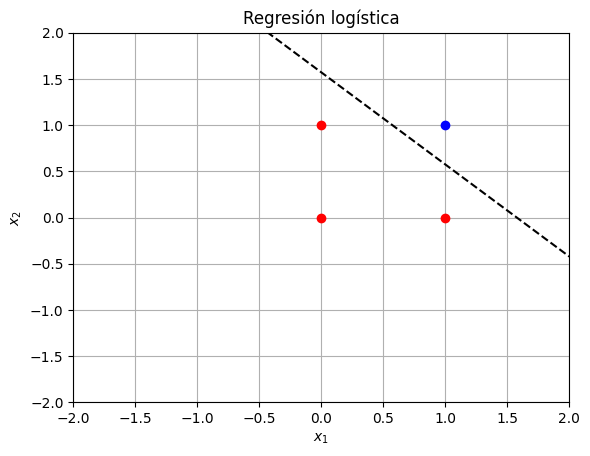

In [3]:
# Ejemplo
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array([0, 0, 0, 1])

neuron = Logistic_Neuron(2, 1)
neuron.train(X,Y)
print(neuron.predict_proba(X))
print(neuron.predict(X))

def draw_2d_percep(model):
  w1, w2, b = model.w[0], model.w[1], model.b
  plt.plot([-2, 2],[(1/w2)*(-w1*(-2)-b),(1/w2)*(-w1*2-b)],'--k')

# Primero dibujemos los puntos
_, p = X.shape
for i in range(p):
  if Y[i] == 0:
    plt.plot(X[0,i],X[1,i], 'or')
  else:
    plt.plot(X[0,i],X[1,i], 'ob')

plt.title('Regresión logística')
plt.grid('on')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
draw_2d_percep(neuron)
plt.show()

##Cargar y preprocesar el dataset `cancer.csv`

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar el dataset
df = pd.read_csv('/content/cancer.csv')
print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (683, 10)


,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,5,1,1,1,2,1,3,1,1,1
1,5,4,4,5,7,10,3,2,1,1
2,3,1,1,1,2,2,3,1,1,1
3,6,8,8,1,3,4,3,7,1,1
4,4,1,1,3,2,1,3,1,1,1


In [5]:
#  Separar características (X) y etiquetas (Y)
X_raw = df.iloc[:, :-1].values
Y_raw = df.iloc[:, -1].values

# Normalizar las características para optimizar la convergencia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Dividir en entrenamiento y test
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_raw, test_size=0.2, random_state=42)

# X.shape -> (n_inputs, n_muestras)
X_train_t = X_train.T
X_test_t = X_test.T

print("Forma de X de entrenamiento adaptada:", X_train_t.shape)
print("Forma de Y de entrenamiento:", Y_train.shape)

Forma de X de entrenamiento adaptada: (9, 546)
Forma de Y de entrenamiento: (546,)


### Instanciar, entrenar y evaluar la neurona logística

In [8]:
# 3. Instanciar la neurona con el número de entradas (features) correspondientes
n_inputs = X_train_t.shape[0]
cancer_neuron = Logistic_Neuron(n_inputs=n_inputs, learning_rate=0.1)

# 4. Entrenar la neurona
cancer_neuron.train(X_train_t, Y_train, epochs=500)

# 5. Realizar predicciones en el conjunto de prueba
Y_pred = cancer_neuron.predict(X_test_t)

# 6. Calcular la precisión (Accuracy)
accuracy = np.mean(Y_pred == Y_test) * 100
print(f"Precisión (Accuracy) en el conjunto de prueba: {accuracy:.2f}%")

Precisión (Accuracy) en el conjunto de prueba: 96.35%


### Entrenamiento

In [11]:
import numpy as np

# --- 1. Preparación de los datos

X_f = X_train_t
Y_f = Y_train.reshape(1, -1) # Convertimos a vector fila (1, n_muestras) para operar matricialmente

n_features, p_samples = X_f.shape
print(f"Entrenando con {n_features} características y {p_samples} muestras.")

# --- 2. Inicialización de parámetros ---
np.random.seed(42) # Para reproducibilidad
W = -1 + 2 * np.random.rand(1, n_features)
b = -1 + 2 * np.random.rand()
eta = 0.1
epochs = 1000

for epoch in range(epochs):
    Z = np.dot(W, X_f) + b

    Y_est = 1 / (1 + np.exp(-Z))

    error = Y_f - Y_est

    W += (eta / p_samples) * np.dot(error, X_f.T)
    b += (eta / p_samples) * np.sum(error)

    if epoch % 100 == 0:
        loss = -np.mean(Y_f * np.log(Y_est + 1e-15) + (1 - Y_f) * np.log(1 - Y_est + 1e-15))
        print(f"Época {epoch:4d} | Pérdida (Loss): {loss:.5f}")


Entrenando con 9 características y 546 muestras.
Época    0 | Pérdida (Loss): 0.74293
Época  100 | Pérdida (Loss): 0.09996
Época  200 | Pérdida (Loss): 0.08845
Época  300 | Pérdida (Loss): 0.08427
Época  400 | Pérdida (Loss): 0.08192
Época  500 | Pérdida (Loss): 0.08036
Época  600 | Pérdida (Loss): 0.07924
Época  700 | Pérdida (Loss): 0.07841
Época  800 | Pérdida (Loss): 0.07776
Época  900 | Pérdida (Loss): 0.07726

¡Entrenamiento completado!


### Evaluación

In [12]:

X_test_f = X_test_t
Y_test_f = Y_test.reshape(1, -1)

Z_test = np.dot(W, X_test_f) + b
Y_est_test = 1 / (1 + np.exp(-Z_test))

# Clasificación usando un umbral de 0.5
Y_pred_f = 1 * (Y_est_test > 0.5)

# Calcular la precisión
accuracy_f = np.mean(Y_pred_f == Y_test_f) * 100
print(f"Precisión final (Accuracy) en prueba: {accuracy_f:.2f}%")

Precisión final (Accuracy) en prueba: 95.62%


# Reporte de Resultados - Clasificación de Cáncer con Neurona Logística

### 1. Dataset seleccionado
*   **Archivo:** `cancer.csv`
*   **Estructura:** 683 filas y 10 columnas.
*   **Características (Inputs):** 9 variables clínicas normalizadas con `StandardScaler`.
*   **Variable objetivo (Output):** Diagnóstico (binario, 0 o 1).

### 2. Implementación de la Neurona Logística (Fórmulas desde cero)
Se programó el entrenamiento utilizando las siguientes ecuaciones fundamentales:
*   **Combinación lineal:** $Z = W \cdot X + b$
*   **Activación (Sigmoide):** $\hat{Y} = \sigma(Z) = \frac{1}{1 + e^{-Z}}$
*   **Actualización de parámetros por Descenso de Gradiente:**
    $$W \leftarrow W + \frac{\eta}{p} (Y - \hat{Y}) X^T$$
    $$b \leftarrow b + \frac{\eta}{p} \sum (Y - \hat{Y})$$

### 3. Resultados obtenidos (Umbral = 0.5)
*   **Épocas de entrenamiento:** 1,000
*   **Tasa de aprendizaje ($\eta$):** 0.1
*   **Pérdida (Loss) final en entrenamiento:** ~0.077
*   **Porcentaje de diagnósticos acertados (Accuracy) en prueba:** **95.62%**